In [1]:
import os
import pickle
from pathlib import Path
from pprint import pprint

import numpy as np
from matplotlib import pyplot as plt

import torch
import scipy

In [2]:
experiment_folder = Path(os.path.join(Path.cwd().parent, 'experiment_data'))

In [5]:
with open(experiment_folder / 'l1-tickets-e50-t15-s30-r0.9000.pkl', 'rb') as f:
    result = pickle.load(f)

In [6]:
result.keys()

dict_keys(['seeds', 'config', 'FC-train-losses', 'FC-train-accs', 'FC-test-losses', 'FC-test-accs', 'model-initializations', 'model-params', 'pruned-train-losses-before', 'pruned-train-accs-before', 'pruned-test-losses-before', 'pruned-test-accs-before', 'ticket-params', 'pruned-train-losses-after', 'pruned-train-accs-after', 'pruned-test-losses-after', 'pruned-test-accs-after', 'input-file-keys'])

In [7]:
param_bucket = torch.tensor([])

In [8]:
torch.concat([param_bucket, torch.tensor([1, 2, 3])])

tensor([1., 2., 3.])

In [9]:
for params in result['model-params']:
    for vals in params.values():
        param_bucket = torch.concat([param_bucket, vals.flatten()])

In [10]:
param_values = param_bucket.abs().numpy()
param_values

array([1.6190823e-04, 2.3077864e-05, 1.3771863e-07, ..., 6.5572432e-04,
       1.9793287e-01, 8.7811530e-02], shape=(357900,), dtype=float32)

In [11]:
kde_model = scipy.stats.gaussian_kde(param_values, bw_method='scott')

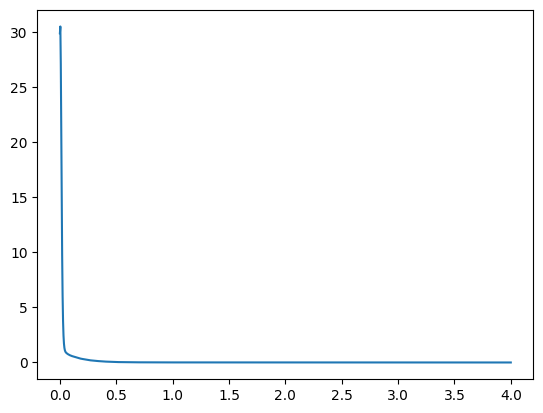

In [12]:
x = np.linspace(0, 4, 1000)
y = kde_model(x)
plt.plot(x, y)
# plt.ylim(0, 1)

(0.0, 2.0)

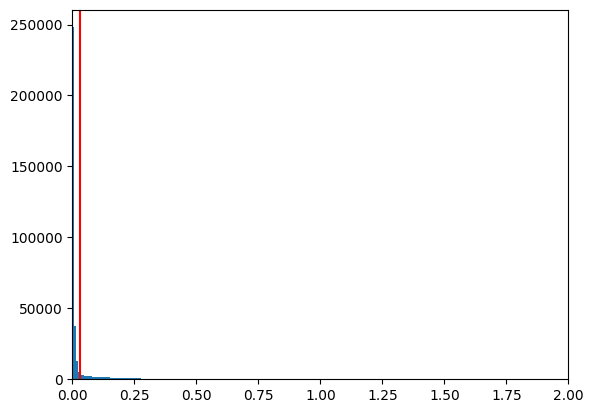

In [13]:
_ = plt.hist(param_values, bins=500)
# plt.ylim(0, 1000)
plt.axvline(0.03, c='r')
plt.xlim(0, 2.)
# 50

In [14]:
(param_values > 0.10).sum() / param_values.shape[0]

np.float64(0.096035205364627)

In [16]:
pprint(list(result.keys()))

['seeds',
 'config',
 'FC-train-losses',
 'FC-train-accs',
 'FC-test-losses',
 'FC-test-accs',
 'model-initializations',
 'model-params',
 'pruned-train-losses-before',
 'pruned-train-accs-before',
 'pruned-test-losses-before',
 'pruned-test-accs-before',
 'ticket-params',
 'pruned-train-losses-after',
 'pruned-train-accs-after',
 'pruned-test-losses-after',
 'pruned-test-accs-after',
 'input-file-keys']


In [17]:
result['FC-test-accs']

[0.964199960231781,
 0.9648000001907349,
 0.9634999632835388,
 0.9646999835968018,
 0.9603999853134155,
 0.9645999670028687,
 0.965499997138977,
 0.9642999768257141,
 0.9690999984741211,
 0.9635999798774719,
 0.9633999466896057,
 0.9649999737739563,
 0.9660999774932861,
 0.9605000019073486,
 0.9659000039100647]

In [18]:
result['pruned-test-accs-after']

[0.9358999729156494,
 0.930899977684021,
 0.9378999471664429,
 0.9293999671936035,
 0.9369999766349792,
 0.9330999851226807,
 0.9337999820709229,
 0.9364999532699585,
 0.9343999624252319,
 0.9381999969482422,
 0.9373999834060669,
 0.9376999735832214,
 0.9309999942779541,
 0.9327999949455261,
 0.9382999539375305]